# Sales Data Analysis using Python

## Project Objective
The objective of this project is to perform Exploratory Data Analysis (EDA) on sales data using Python.  
The goal is to understand customer behavior, identify important customer segments, find top-performing states, product categories, and professions, and generate business insights from the data.

## Tools & Libraries Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Import Data

In [2]:
df = pd.read_csv("Sales_Data.csv", encoding="unicode_escape")

## Basic Check

In [3]:
df.shape

(11257, 13)

In [4]:
df.head()

,User_ID,Cust_name,Product_ID,Age,Age Group,Gender,State,Zone,Zipcode,Profession,Product_Category,Orders,Amount
0,1002903.0,Anvi,P00125942,27.0,26-35,Female,Maharashtra,West,NaN,Healthcare,Sports,4.0,20500.0
1,1000732.0,Shanta,P00110942,34.0,26-35,Female,Andhra Pradesh,South,NaN,Govt,Sports,2.0,25360.0
2,1001990.0,Sheetal,P00118542,16.0,0-17,Female,Uttar Pradesh,Central,NaN,Automobile,Health,4.0,29350.0
3,1001425.0,Virendra,P00237842,16.0,0-17,M,Karnataka,South,NaN,Construction,Clothing,6.0,23500.0
4,1000588.0,Vishal,P00057942,28.0,26-35,M,Gujarat,West,NaN,Food Processing,Electronics,4.0,23870.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11257 entries, 0 to 11256
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11245 non-null  float64
 1   Cust_name         11245 non-null  object 
 2   Product_ID        11245 non-null  object 
 3   Age               11245 non-null  float64
 4   Age Group         11245 non-null  object 
 5   Gender            11245 non-null  object 
 6   State             11245 non-null  object 
 7   Zone              11245 non-null  object 
 8   Zipcode           0 non-null      float64
 9   Profession        11245 non-null  object 
 10  Product_Category  11245 non-null  object 
 11  Orders            11245 non-null  float64
 12  Amount            11245 non-null  float64
dtypes: float64(5), object(8)
memory usage: 1.1+ MB


## Data Cleaning

In [6]:
df.drop(["Zipcode"], axis=1, inplace=True)

In [7]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Age', 'Age Group', 'Gender',
       'State', 'Zone', 'Profession', 'Product_Category', 'Orders', 'Amount'],
      dtype='object')

In [8]:
pd.isnull(df).sum()

User_ID             12
Cust_name           12
Product_ID          12
Age                 12
Age Group           12
Gender              12
State               12
Zone                12
Profession          12
Product_Category    12
Orders              12
Amount              12
dtype: int64

In [9]:
df[df["User_ID"].isnull()]

,User_ID,Cust_name,Product_ID,Age,Age Group,Gender,State,Zone,Profession,Product_Category,Orders,Amount
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
139,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df.dropna(how="all", inplace=True)

In [11]:
pd.isnull(df).sum()

User_ID             0
Cust_name           0
Product_ID          0
Age                 0
Age Group           0
Gender              0
State               0
Zone                0
Profession          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

In [12]:
df["Gender"].unique()

array(['Female', 'M'], dtype=object)

In [13]:
df["Gender"] = df["Gender"].replace({"M" : "Male"})

In [14]:
df.head()

,User_ID,Cust_name,Product_ID,Age,Age Group,Gender,State,Zone,Profession,Product_Category,Orders,Amount
0,1002903.0,Anvi,P00125942,27.0,26-35,Female,Maharashtra,West,Healthcare,Sports,4.0,20500.0
1,1000732.0,Shanta,P00110942,34.0,26-35,Female,Andhra Pradesh,South,Govt,Sports,2.0,25360.0
2,1001990.0,Sheetal,P00118542,16.0,0-17,Female,Uttar Pradesh,Central,Automobile,Health,4.0,29350.0
3,1001425.0,Virendra,P00237842,16.0,0-17,Male,Karnataka,South,Construction,Clothing,6.0,23500.0
4,1000588.0,Vishal,P00057942,28.0,26-35,Male,Gujarat,West,Food Processing,Electronics,4.0,23870.0


In [15]:
df.duplicated().sum()

np.int64(2)

In [16]:
df[df.duplicated(keep=False)]

,User_ID,Cust_name,Product_ID,Age,Age Group,Gender,State,Zone,Profession,Product_Category,Orders,Amount
4005,1004658.0,Guy,P00249542,34.0,26-35,Male,Andhra Pradesh,South,Aviation,Sports,3.0,10270.0
4006,1004658.0,Guy,P00249542,34.0,26-35,Male,Andhra Pradesh,South,Aviation,Sports,3.0,10270.0
5708,1003208.0,Bowman,P00171642,31.0,26-35,Female,Bihar,East,Agriculture,Sports,1.0,8088.0
5709,1003208.0,Bowman,P00171642,31.0,26-35,Female,Bihar,East,Agriculture,Sports,1.0,8088.0


In [17]:
df = df.drop_duplicates()

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
# To fix the pink boxes from appearing
df = df.copy()

In [20]:
df["User_ID"] = df["User_ID"].astype("object")
df["Age"] = df["Age"].astype("int64")
df["Orders"] = df["Orders"].astype("int64")

In [21]:
df.dtypes

User_ID              object
Cust_name            object
Product_ID           object
Age                   int64
Age Group            object
Gender               object
State                object
Zone                 object
Profession           object
Product_Category     object
Orders                int64
Amount              float64
dtype: object

## Data Cleaning Steps
- Imported the sales dataset using Pandas.
- Checked dataset shape, columns, data types, and basic information.
- Removed unnecessary columns from the dataset.
- Checked and removed null values.
- Checked and removed duplicate records.
- Converted the Amount column into integer data type for analysis.
- Prepared the dataset for Exploratory Data Analysis.

## Exploratory Data Analysis Questions
This project answers business questions such as:
- Which gender has the highest number of transactions?
- Which age group contributes the most to sales?
- Which states generate the highest sales and quantity ordered?
- Which product categories perform best?
- Which professions contribute the most to sales?
- Which products are ordered the most?

## Exploratory Data Analysis

In [22]:
df.describe()

,Age,Orders,Amount
count,11243.000000,11243.000000,11243.000000
mean,35.416170,3.500578,9461.984567
std,12.757428,1.713690,5234.870641
min,12.000000,1.000000,188.000000
25%,27.000000,2.000000,5443.000000
50%,33.000000,4.000000,8109.000000
75%,43.000000,5.000000,12686.000000
max,92.000000,6.000000,29350.000000


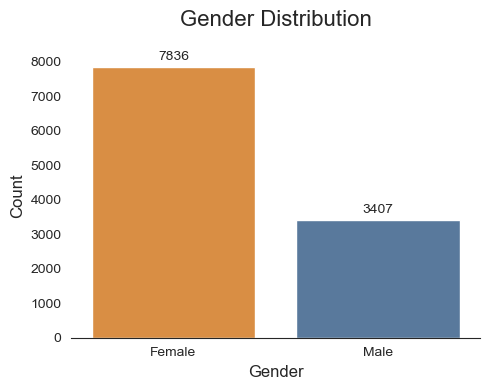

In [23]:
# Total Transaction Count by Gender wise.

plt.figure(figsize=(5, 4), dpi=100)
sns.set_style("white")

modern_colors = ["#f28e2b", "#4e79a7"] # color palette (Soft Coral and Slate Blue)
ax = sns.countplot(x = "Gender", data = df, hue="Gender", palette=modern_colors, legend=False)

for bars in ax.containers :
    ax.bar_label(bars, padding=3)
    
ax.set_title("Gender Distribution", fontsize=16, pad=20)
ax.set_xlabel("Gender", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.tick_params(axis="both", labelsize=10)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

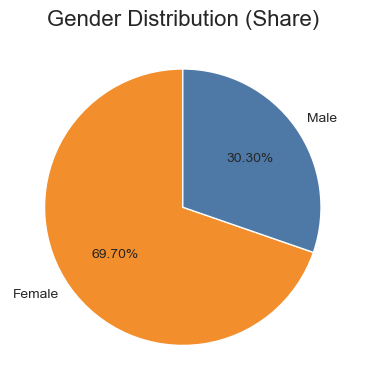

In [24]:
# Gender wise Distribution.

plt.figure(figsize=(4, 4), dpi=100)
sns.set_style("white")

gender_counts = df["Gender"].value_counts()

modern_colors = ["#f28e2b", "#4e79a7"] # color palette (Soft Coral and Slate Blue)

plt.pie(gender_counts, labels=gender_counts.index, autopct="%1.2f%%", colors=modern_colors, startangle=90)

plt.title("Gender Distribution (Share)", fontsize=16)
plt.tight_layout()
plt.show()

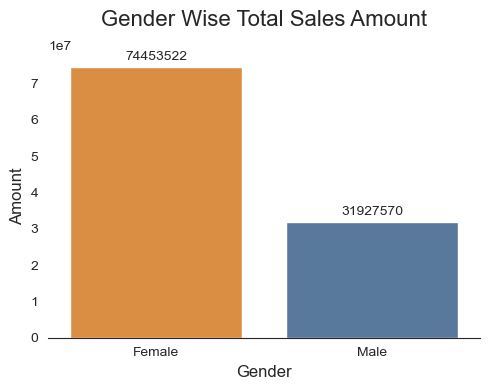

In [25]:
# Gender wise Total Sales Amount.

plt.figure(figsize=(5,4), dpi=100)
sns.set_style("white")

Gen_wise_sales = df.groupby("Gender", as_index=False)["Amount"].sum().sort_values("Amount",ascending=False)

modern_colors = ["#f28e2b", "#4e79a7"]
ax = sns.barplot(x = "Gender", y = "Amount",data = Gen_wise_sales, hue="Gender", palette=modern_colors, legend=False)

for bars in ax.containers :
    ax.bar_label(bars, fmt="%0.f", padding=3)
    
ax.set_title("Gender Wise Total Sales Amount", fontsize=16, pad=20)
ax.set_xlabel("Gender", fontsize=12)
ax.set_ylabel("Amount", fontsize=12)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

### Business Insight
Female customers contribute more transactions and sales compared to male customers. Marketing campaigns targeted toward female customers may generate higher returns.

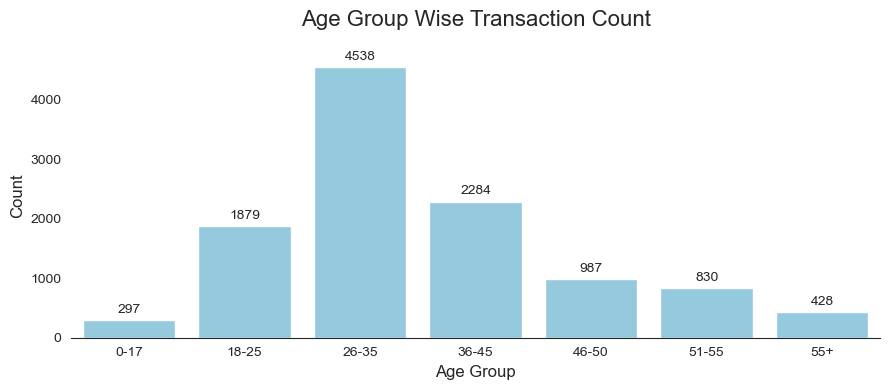

In [26]:
## Age Group Wise Transaction Count.

plt.figure(figsize=(9,4), dpi=100)
sns.set_style("white")

age_order = ["0-17", "18-25", "26-35", "36-45", "46-50", "51-55", "55+"]

ax = sns.countplot(x = "Age Group", data = df, color="skyblue", order = age_order)

for bars in ax.containers :
    ax.bar_label(bars, padding=3)
    
ax.set_title("Age Group Wise Transaction Count", fontsize=16, pad=20)
ax.set_xlabel("Age Group", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
    
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

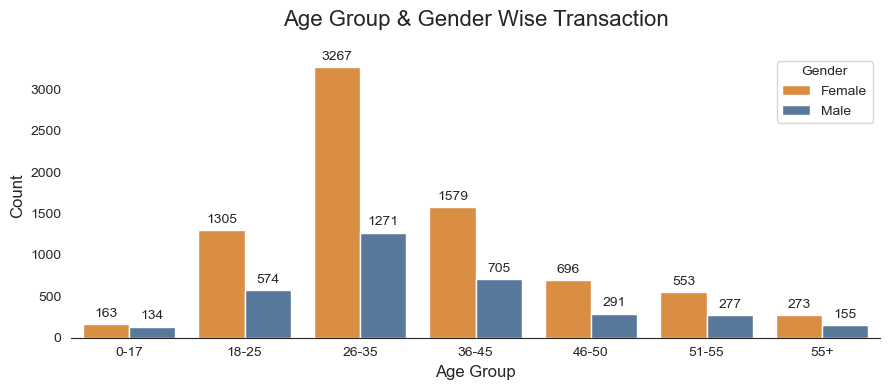

In [27]:
# Age Group and Gender wise Trasactions distribution.

plt.figure(figsize=(9,4), dpi=100)
sns.set_style("white")

age_order = ["0-17", "18-25", "26-35", "36-45", "46-50", "51-55", "55+"]

modern_colors = ["#f28e2b", "#4e79a7"]
ax = sns.countplot(x = "Age Group", data = df, hue = "Gender", palette=modern_colors, order = age_order)

for bars in ax.containers:
    ax.bar_label(bars, padding=3)

plt.title("Age Group & Gender Wise Transaction", fontsize=16, pad=20)
ax.set_xlabel("Age Group", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

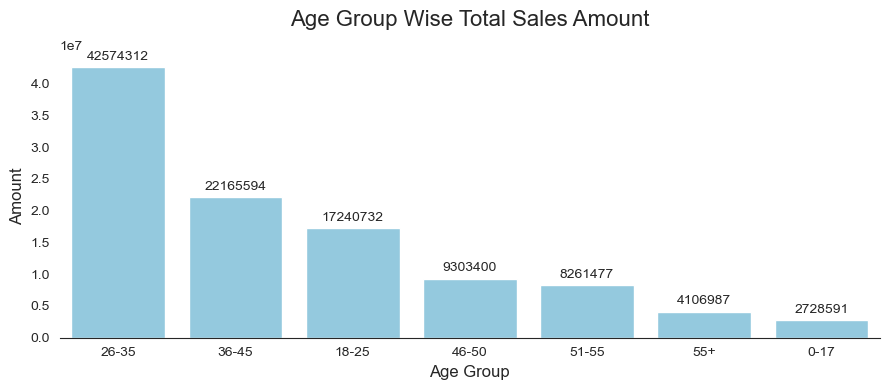

In [28]:
# Age Group wise Total Amount.

plt.figure(figsize=(9,4), dpi=100)
sns.set_style("white")

agegroup_sales = df.groupby(["Age Group"], as_index=False)["Amount"].sum().sort_values("Amount", ascending = False)

ax = sns.barplot(x = "Age Group", y = "Amount",data = agegroup_sales, color = "skyblue")

for bars in ax.containers:
    ax.bar_label(bars, fmt="%0.f", padding=3)
    
ax.set_title("Age Group Wise Total Sales Amount", fontsize=16, pad=20)  
ax.set_xlabel("Age Group", fontsize=12)
ax.set_ylabel("Amount", fontsize=12)

# plt.ticklabel_format(style='plain', axis='y')
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

### Business Insight
Customers aged 26–35 represent the most valuable customer segment. The company can focus on personalized offers and loyalty programs for this age group.

## State wise Analysis

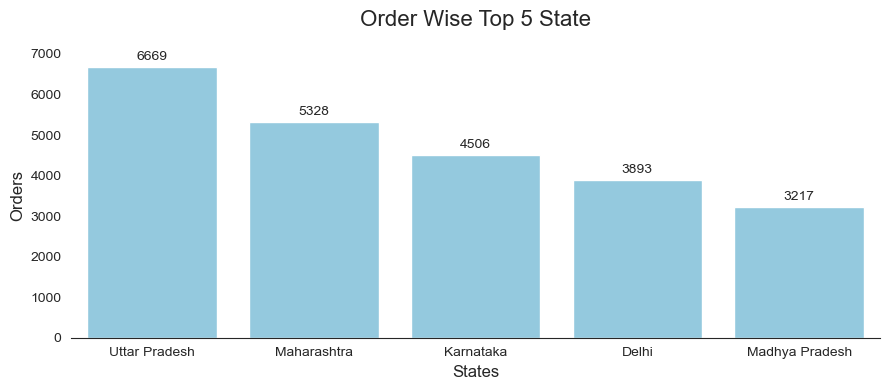

In [29]:
# Order wise Top 5 State.

plt.figure(figsize=(9,4), dpi=100)
sns.set_style("white")

state_orders = df.groupby(["State"], as_index=False)["Orders"].sum().sort_values("Orders", ascending=False).head()

ax = sns.barplot(x = "State", y = "Orders" ,data = state_orders, color="skyblue")

for bars in ax.containers:
    ax.bar_label(bars, fmt="%0.f", padding=3)

ax.set_title("Order Wise Top 5 State", fontsize=16, pad=20)
ax.set_xlabel("States", fontsize=12)
ax.set_ylabel("Orders", fontsize=12)


sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

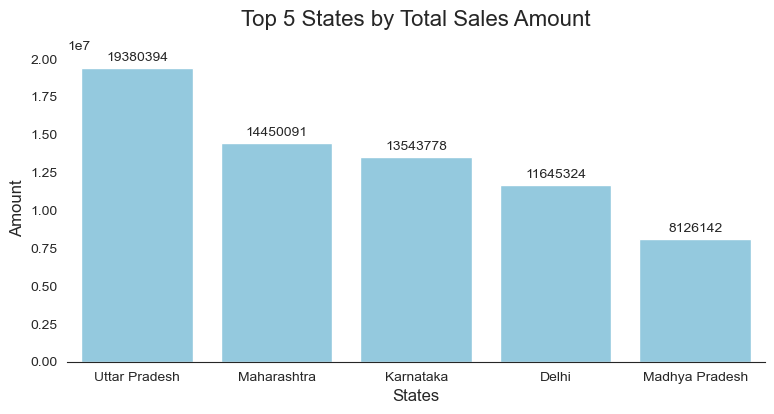

In [30]:
# Top 5 States by Total Sales Amount.

plt.figure(figsize=(9,4), dpi=100)
sns.set_style("white")

state_amounts = df.groupby(["State"], as_index=False)["Amount"].sum().sort_values("Amount", ascending=False).head()

ax = sns.barplot(x = "State", y = "Amount", data = state_amounts, color="skyblue")

for bars in ax.containers:
    ax.bar_label(bars, fmt="%0.f", padding=3)

ax.set_title("Top 5 States by Total Sales Amount", fontsize=16, pad=20)
ax.set_xlabel("States", fontsize=12)
ax.set_ylabel("Amount", fontsize=12)

# plt.ticklabel_format(style="plain", axis="y")

sns.despine(left=True, bottom=False)
plt.show()

### Business Insight
Uttar Pradesh, Maharashtra, and Karnataka generate the highest sales. Inventory planning and regional promotions should be prioritized in these states.

## Product_Category Analysis

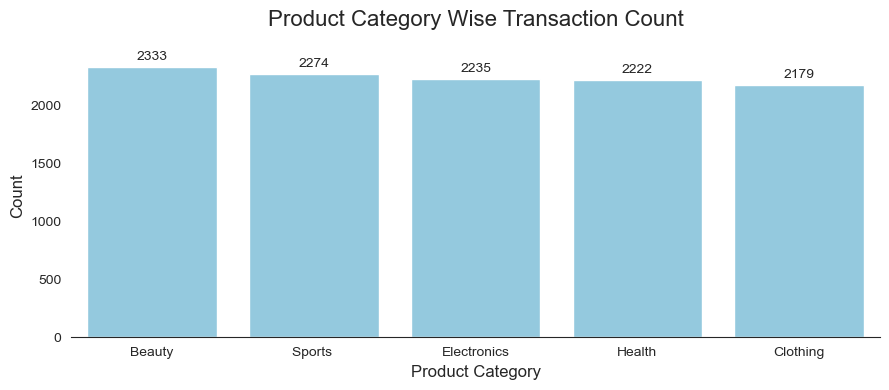

In [31]:
# Product Caategory wise Transaction Count.

plt.figure(figsize=(9,4), dpi=100)
sns.set_style("white")

category_order = df["Product_Category"].value_counts().index

ax = sns.countplot(x = "Product_Category", data = df, color="skyblue", order=category_order)

for bars in ax.containers:
    ax.bar_label(bars, padding=3)

ax.set_title("Product Category Wise Transaction Count", fontsize=16, pad=20)
ax.set_xlabel("Product Category", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

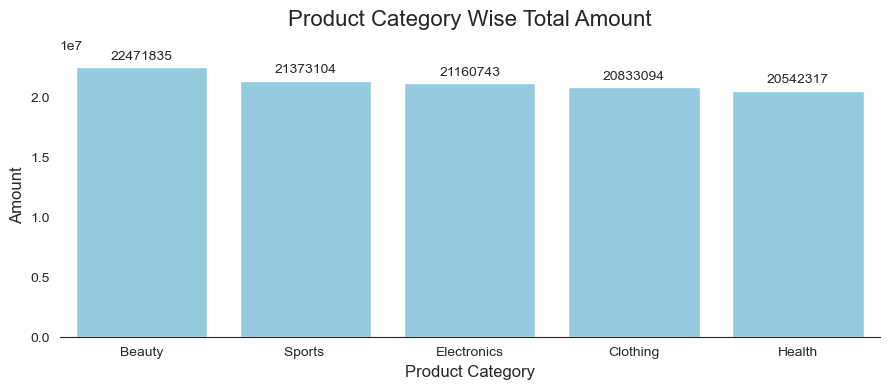

In [38]:
# Amount wise Product Category.

plt.figure(figsize=(9,4), dpi=100)
sns.set_style("white")

category_amount = df.groupby(["Product_Category"], as_index=False)["Amount"].sum().sort_values("Amount", ascending=False)

ax = sns.barplot(x = "Product_Category", y = "Amount" ,data = category_amount, color = "skyblue")

for bars in ax.containers:
    ax.bar_label(bars, fmt="%0.f" ,padding=3)

ax.set_title("Product Category Wise Total Amount", fontsize=16, pad=20)
ax.set_xlabel("Product Category", fontsize=12)
ax.set_ylabel("Amount", fontsize=12)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

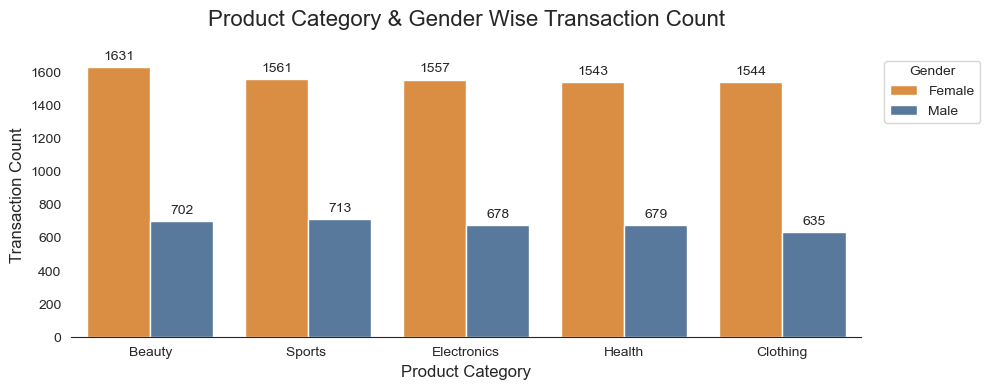

In [33]:
# Product Category and Gender wise Transaction Count.

plt.figure(figsize=(10,4), dpi=100)
sns.set_style("white")

modern_colors = ["#f28e2b", "#4e79a7"]
category_gender_order = df["Product_Category"].value_counts().index

ax = sns.countplot(x = "Product_Category", data = df, hue = "Gender", palette=modern_colors, order=category_gender_order)

for bars in ax.containers:
    ax.bar_label(bars, fmt="%0.f", padding=3)

ax.set_title("Product Category & Gender Wise Transaction Count", fontsize=16, pad=20)
ax.set_xlabel("Product Category", fontsize=12)
ax.set_ylabel("Transaction Count", fontsize=12)

plt.legend(title="Gender", bbox_to_anchor=(1.02, 1), loc="upper left")
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

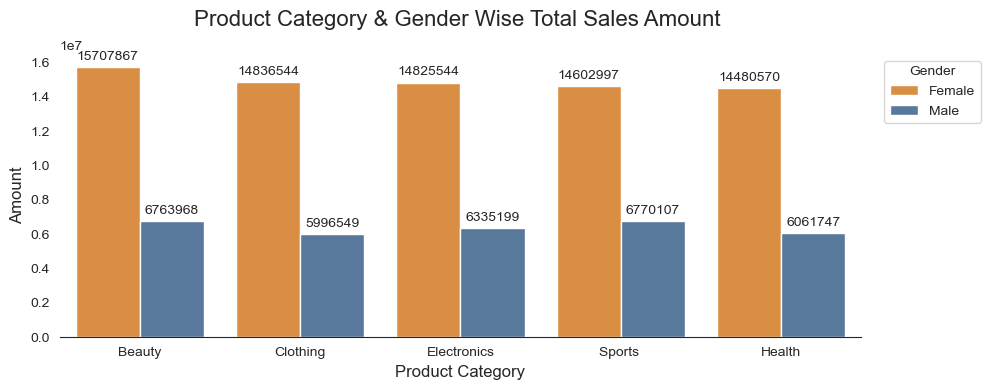

In [34]:
# Product Category and Gender wise Total Sales Amount.

plt.figure(figsize=(10,4), dpi=100)

modern_colors = ["#f28e2b", "#4e79a7"]
category_gender = df.groupby(["Product_Category", "Gender"], as_index=False).sum().sort_values("Amount", ascending=False)

ax = sns.barplot(x = "Product_Category", y = "Amount", data = category_gender, hue = "Gender", palette=modern_colors)

for bars in ax.containers:
    ax.bar_label(bars, fmt="%0.f" ,padding=3)

ax.set_title("Product Category & Gender Wise Total Sales Amount ", fontsize=16, pad=20)
ax.set_xlabel("Product Category", fontsize=12)
ax.set_ylabel("Amount", fontsize=12)

plt.legend(title="Gender", bbox_to_anchor=(1.02,1), loc="upper left")
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

### Business Insight
Beauty, Sports, and Electronics categories contribute significantly to sales. These categories should receive greater marketing and stocking priority.

## Profession wise Analysis

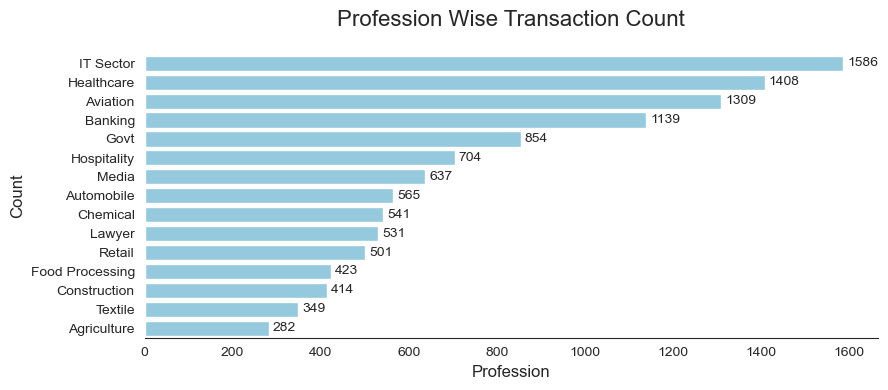

In [35]:
# Profession wise Transaction Count.

plt.figure(figsize=(9,4), dpi=100)
sns.set_style("white")

prof_order = df["Profession"].value_counts().index

ax = sns.countplot(y = "Profession", data = df, color="skyblue", order=prof_order)

for bars in ax.containers:
    ax.bar_label(bars, padding=3)

ax.set_title("Profession Wise Transaction Count", fontsize=16, pad=20)
ax.set_xlabel("Profession", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

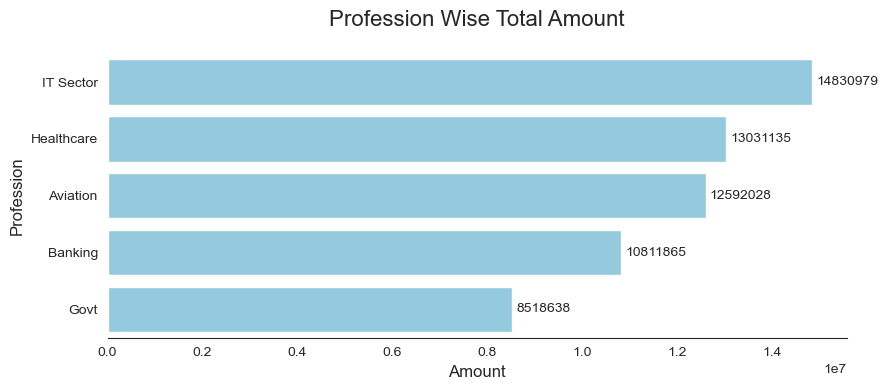

In [39]:
# Amount wise Top 5 Profession.

plt.figure(figsize=(9,4), dpi=100)
sns.set_style("white")

prof_amount = df.groupby(["Profession"], as_index=False)["Amount"].sum().sort_values("Amount", ascending=False).head()

ax = sns.barplot(x = "Amount", y = "Profession", data = prof_amount, color="skyblue")

for bars in ax.containers:
    ax.bar_label(bars, fmt="%0.f", padding=3)

ax.set_title("Profession Wise Total Amount", fontsize=16, pad=20)
ax.set_xlabel("Amount", fontsize=12)
ax.set_ylabel("Profession", fontsize=12)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

### Business Insight
Customers working in IT, Healthcare, and Aviation sectors contribute the most sales. Profession-based campaigns can improve customer targeting.

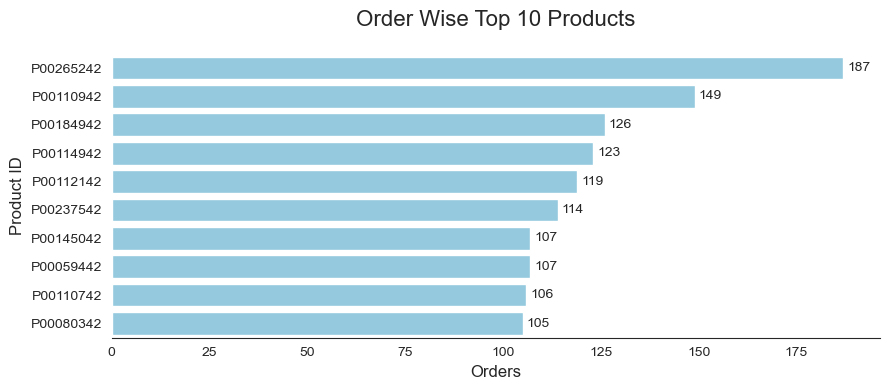

In [37]:
# Order wise Top 10 Product.

plt.figure(figsize=(9,4), dpi=100)
sns.set_style("white")

order_product = df.groupby(["Product_ID"], as_index=False)["Orders"].sum().sort_values("Orders", ascending=False).head(10)

ax = sns.barplot(x = "Orders", y = "Product_ID", data = order_product, color="skyblue")

for bars in ax.containers:
    ax.bar_label(bars, padding=3)

ax.set_title("Order Wise Top 10 Products", fontsize=16, pad=20)
ax.set_xlabel("Orders", fontsize=12)
ax.set_ylabel("Product ID", fontsize=12)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()
    

## Key Insights
- Female customers are more active buyers compared to male customers.
- Customers from the 26–35 age group contribute the highest number of transactions and sales amount.
- Uttar Pradesh, Maharashtra, and Karnataka are among the top-performing states.
- Beauty, Sports, and Electronics are strong-performing product categories.
- Customers working in IT, Healthcare, and Aviation professions contribute significantly to total sales.
- Some specific products have higher quantity demand and can be considered best-selling products.

## Business Recommendations
- The company should focus more marketing campaigns on female customers because they generate higher sales.
- The 26–35 age group should be targeted with personalized offers and discounts.
- Top-performing states like Uttar Pradesh, Maharashtra, and Karnataka should receive more inventory and promotional focus.
- High-performing categories such as Beauty, Sports, and Electronics can be promoted during festive or seasonal sales.
- Professions with higher sales contribution, such as IT, Healthcare, and Aviation, can be targeted through profession-based campaigns.

## Final Conclusion
From this analysis, we can conclude that women aged 26–35 years from Uttar Pradesh, Maharashtra, and Karnataka, working in IT, Healthcare, and Aviation sectors, are more likely to buy products from Beauty, Sports, and Electronics categories.


## Skills Demonstrated

- Data Cleaning using Pandas
- Data Transformation
- Missing Value Handling
- Duplicate Detection and Removal
- Exploratory Data Analysis (EDA)
- Data Aggregation using GroupBy
- Data Visualization using Matplotlib
- Business Insight Generation
- Customer Segmentation Analysis